# H0 Selective-EB LR Branch Replacement

## 목표

기준 H0의 `0.80 × 구조화 LR + 0.20 × fold-local LGBM hard specialist`에서 **LGBM 및 specialist를 전혀 바꾸지 않고**, 80% LR 분기만 fold-train Empirical-Bayes LR과 고정 margin gate로 대체한다.

- H0: `0.80 × H0 LR + 0.20 × 기존 specialist LGBM`
- 후보: `0.80 × Selective-EB LR + 0.20 × 동일 specialist LGBM`

`0.05` margin, `0.80/0.20` 가중치, LR/LGBM 파라미터는 사전에 고정한다. 이 노트북은 기본값에서 결과만 읽으며, 전체 CV는 `RUN_EXPERIMENT=True`일 때만 실행한다.

## 규정·누수 계약

- OOF screen은 `train.csv`만 읽고 `test.csv`를 읽지 않는다.
- train/test 결합, test 기반 vocabulary·통계·스케일링·피처 선택을 하지 않는다.
- gene×event-type vocabulary와 EB 통계는 outer-fold train에서만 fit한다.
- validation은 transform/evaluation만 수행한다.
- 고정 암종명·유전자명·exact mutation 목록을 사용하지 않는다.
- WT/빈 문자열/NaN은 event가 아니며 `nan_as_mutation_count == 0`을 확인한다.
- fold별 atomic checkpoint를 `result/`에 저장하므로 중단 후 같은 명령으로 재개한다.

In [8]:
from pathlib import Path
import subprocess, sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
EXPERIMENT = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_007'
RUNNER = EXPERIMENT / 'common' / 'h0_selective_eb_replacement_runner.py'
RESULT = EXPERIMENT / 'result'
RUN_ID = 'exp-h0-selective-eb-branch-replacement-01'
SEEDS = (42,777,2024)  # screen 통과 시 (42, 777, 2024)로 한 번만 확장
RUN_EXPERIMENT = True
assert RUNNER.exists() and (ROOT / 'data' / 'raw' / 'train.csv').exists()
{'runner': RUNNER, 'result_dir': RESULT, 'seeds': SEEDS}

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_007/common/h0_selective_eb_replacement_runner.py'),
 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_007/result'),
 'seeds': (42, 777, 2024)}

### 1. 실행 전 smoke test

parser/확률 결합/경로 계약만 확인한다. 전체 CV는 실행하지 않는다.

In [9]:
subprocess.run([sys.executable, str(RUNNER), '--smoke'], check=True)

{"smoke": "ok", "test_read": false, "nan_as_mutation_count": 0, "fixed_class_gene_mutation_rules": false}


CompletedProcess(args=['/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/bin/python', '/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_007/common/h0_selective_eb_replacement_runner.py', '--smoke'], returncode=0)

### 2. OOF 실행 또는 재개

`RUN_EXPERIMENT=True`로 바꾸면 fold별 checkpoint를 저장한다. 이미 끝난 fold는 건너뛴다.

In [10]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--run-id', RUN_ID, '--seeds', *map(str, SEEDS)]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='H0 selective-EB folds', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('runner failed; checkpoint remains available:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 기존 결과만 읽습니다.')

H0 selective-EB folds: 1line [00:04,  4.86s/line]

[H0 selective EB] seed 42: resume folds [1, 2, 3, 4, 5]
[H0 selective EB] seed 777, fold 1/5: fold-train feature fit


H0 selective-EB folds: 3line [03:43, 82.42s/line]

[H0 selective EB] seed 777, fold 1/5 checkpoint saved
[H0 selective EB] seed 777, fold 2/5: fold-train feature fit


H0 selective-EB folds: 5line [07:43, 101.74s/line]

...

H0 selective-EB folds: 21line [39:46, 121.77s/line]

[H0 selective EB] seed 2024, fold 5/5 checkpoint saved


H0 selective-EB folds: 22line [39:47, 100.06s/line]

{"run_id": "exp-h0-selective-eb-branch-replacement-01", "seeds": [42, 777, 2024], "h0_weight": 0.8, "specialist_weight": 0.2, "selective_margin": 0.05, "threshold_retuned": false, "screen_pass": false, "three_seed_pass": true, "positive_fold_count": 12, "test_read": false, "leakage_check": true, "nan_as_mutation_count": 0, "decision": "accepted_3seed"}


H0 selective-EB folds: 22line [39:47, 108.54s/line]


## 결과·감사

실행 뒤 아래 셀을 순서대로 실행한다. summary/fold/class/audit이 없으면 먼저 위의 실행 셀을 완료한다.

In [11]:
import json
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(RESULT / f'{RUN_ID}_seed_summary.csv')
aggregate = pd.read_csv(RESULT / f'{RUN_ID}_aggregate_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_fold_metrics.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_class_metrics.csv')
audit = json.loads((RESULT / f'{RUN_ID}_leakage_audit.json').read_text())
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
display(summary.sort_values(['seed', 'variant']))
display(aggregate)
audit

,seed,variant,oof_macro_f1,oof_accuracy,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_h0
0,42,H0,0.544744,0.555556,8193.2,0,True,0,0.045732,0.000000
1,42,H0_selective_EB,0.547915,0.558942,8219.2,0,True,0,0.090182,0.003171
2,777,H0,0.538710,0.551685,8188.4,0,True,0,1180.107892,0.000000
3,777,H0_selective_EB,0.543247,0.555394,8214.4,0,True,0,1180.131245,0.004537
4,2024,H0,0.544306,0.556201,8193.0,0,True,0,1201.193036,0.000000
5,2024,H0_selective_EB,0.550605,0.560877,8219.0,0,True,0,1201.216003,0.006299


,variant,seed_count,oof_macro_f1_mean,oof_macro_f1_std,delta_vs_h0_mean,delta_vs_h0_std,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H0,3,0.542587,0.003365,0.000000,0.000000,0,True,0
1,H0_selective_EB,3,0.547256,0.003723,0.004669,0.001568,0,True,0


{'run_id': 'exp-h0-selective-eb-branch-replacement-01',
 'seeds': [42, 777, 2024],
 'h0_weight': 0.8,
 'specialist_weight': 0.2,
 'selective_margin': 0.05,
 'threshold_retuned': False,
 'screen_pass': False,
 'three_seed_pass': True,
 'positive_fold_count': 12,
 'test_read': False,
 'leakage_check': True,
 'nan_as_mutation_count': 0,
 'decision': 'accepted_3seed'}

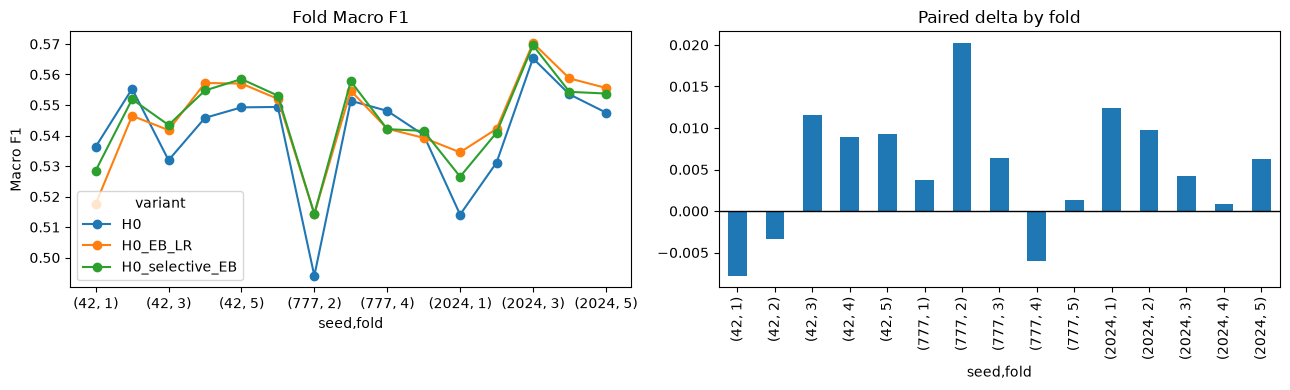

In [12]:
pivot = folds.pivot_table(index=['seed', 'fold'], columns='variant', values='macro_f1')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pivot.plot(marker='o', ax=axes[0], title='Fold Macro F1')
( pivot['H0_selective_EB'] - pivot['H0'] ).plot.bar(ax=axes[1], title='Paired delta by fold')
axes[0].set_ylabel('Macro F1'); axes[1].axhline(0, color='black', lw=1)
plt.tight_layout(); plt.show()

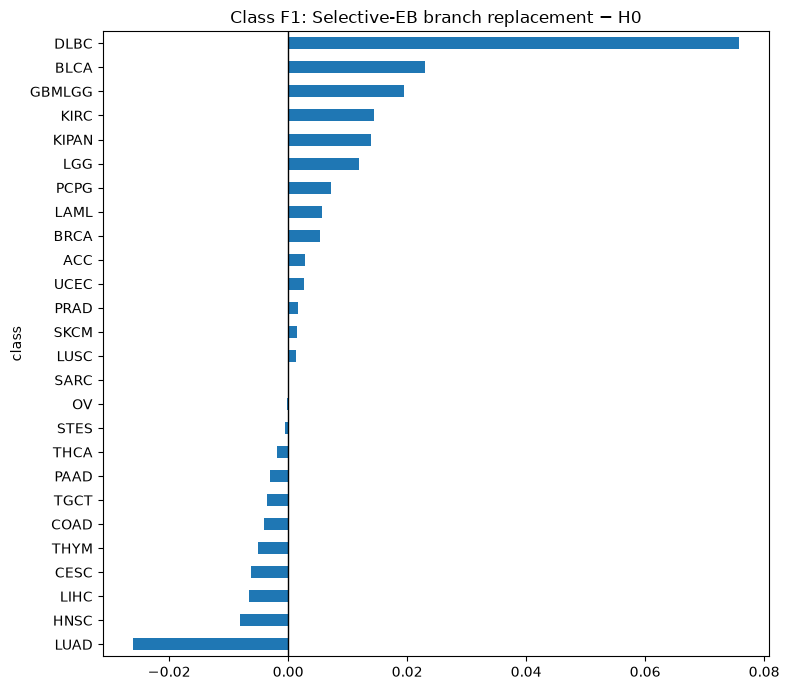

,f1_delta
class,
LUAD,-0.026092
HNSC,-0.008163
LIHC,-0.006619
CESC,-0.006223
THYM,-0.005064
COAD,-0.003977
TGCT,-0.003501
PAAD,-0.003084
THCA,-0.001865


In [13]:
f1 = classes.pivot_table(index=['seed', 'class'], columns='variant', values='f1')
delta = (f1['H0_selective_EB'] - f1['H0']).groupby('class').mean().sort_values()
ax = delta.plot.barh(figsize=(8, 7), title='Class F1: Selective-EB branch replacement − H0')
ax.axvline(0, color='black', lw=1); plt.tight_layout(); plt.show()
display(delta.to_frame('f1_delta'))

## 자동 판정

screen: seed42에서 평균 delta `≥ +0.003` 및 5 folds 중 4개 이상 양수면 3-seed 확정 검증 후보.

3-seed: 새 피처·가중치·threshold를 추가하지 않고 `42/777/2024`에서 모두 양수, 평균 `≥ +0.003`, 15 folds 중 11개 이상 양수여야 채택한다.

In [14]:
decision = audit['decision']
print(f'판정: {decision}')
print(f"positive folds: {audit['positive_fold_count']}")
print(f"fixed threshold: {audit['selective_margin']}, re-tuned: {audit['threshold_retuned']}")

판정: accepted_3seed
positive folds: 12
fixed threshold: 0.05, re-tuned: False
